In [81]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

In [ ]:
account=pd.read_csv(r"C:\Users\saleh\OneDrive\Desktop\CAE-Intern\project\cleanData\clean_account.csv", sep=";")
account.rename(columns={"date": "Account_date"}, inplace=True)
account["district_id"] = account["district_id"].astype(str)
account["account_id"] = account["account_id"].astype(str)
account["Account_date"] = pd.to_datetime(
    account["Account_date"], format="mixed", errors="coerce"
)
# Extract year for EDA
account["account_year"] = account["Account_date"].dt.year

In [84]:
account.head()

,account_id,district_id,frequency,Account_date,account_year
0,576,55,monthly,1993-01-01,1993
1,3818,74,monthly,1993-01-01,1993
2,704,55,monthly,1993-01-01,1993
3,2378,16,monthly,1993-01-01,1993
4,2632,24,monthly,1993-01-02,1993


In [85]:
reference_date = account['Account_date'].max()

# A. Account Tenure & Vintage
account['account_age_days'] = (reference_date - account['Account_date']).dt.days
account['account_age_months'] = (account['account_age_days'] / 30.44).round(1)

account['vintage_year'] = account['Account_date'].dt.year
account['vintage_quarter'] = account['Account_date'].dt.to_period('Q')

# B. Account Recency Flags
account['is_new_account'] = (account['account_age_days'] <= 180).astype(int)
account['is_mature_account'] = (account['account_age_days'] >= 730).astype(int)

# C. District Account Density (Frequency Encoding)
district_counts = account['district_id'].value_counts().to_dict()
account['district_account_density'] = account['district_id'].map(district_counts)
account['district_account_share'] = account['district_account_density'] / len(
    account
)


# ==========================================
# 2. PREPROCESSING & ENCODING
# ==========================================

# Ensure ID columns are treated as strings
account['account_id'] = account['account_id'].astype(str)
account['district_id'] = account['district_id'].astype(str)

# One-Hot Encoding for vintage cohorts
vintage_dummies = pd.get_dummies(
    account['vintage_year'], prefix='vintage', drop_first=True
)
account = pd.concat([account, vintage_dummies], axis=1)


# ==========================================
# 3. HELPER FUNCTION FOR DOWNSTREAM JOINS
# ==========================================


def calculate_tenure_at_loan(loan_df, account_df):
  """Calculates customer relationship age at the exact moment of loan origination."""
  # Ensure date types match before merging
  loan_df['loan_date'] = pd.to_datetime(loan_df['loan_date'])
  account_df['Account_date'] = pd.to_datetime(account_df['Account_date'])

  # Convert keys to string for clean join
  loan_df['account_id'] = loan_df['account_id'].astype(str)
  account_df['account_id'] = account_df['account_id'].astype(str)

  merged = loan_df.merge(
      account_df[['account_id', 'Account_date']], on='account_id', how='left'
  )

  merged['tenure_at_loan_days'] = (
      merged['loan_date'] - merged['Account_date']
  ).dt.days
  merged['tenure_at_loan_months'] = (
      merged['tenure_at_loan_days'] / 30.44
  ).round(1)

  return merged


# ==========================================
# VERIFICATION
# ==========================================
print('Account DataFrame shape:', account.shape)
account.head()

Account DataFrame shape: (4500, 17)


,account_id,district_id,frequency,Account_date,account_year,account_age_days,account_age_months,vintage_year,vintage_quarter,is_new_account,is_mature_account,district_account_density,district_account_share,vintage_1994,vintage_1995,vintage_1996,vintage_1997
0,576,55,monthly,1993-01-01,1993,1823,59.9,1993,1993Q1,0,1,53,0.011778,False,False,False,False
1,3818,74,monthly,1993-01-01,1993,1823,59.9,1993,1993Q1,0,1,135,0.030000,False,False,False,False
2,704,55,monthly,1993-01-01,1993,1823,59.9,1993,1993Q1,0,1,53,0.011778,False,False,False,False
3,2378,16,monthly,1993-01-01,1993,1823,59.9,1993,1993Q1,0,1,52,0.011556,False,False,False,False
4,2632,24,monthly,1993-01-02,1993,1822,59.9,1993,1993Q1,0,1,42,0.009333,False,False,False,False


In [86]:
# List of newly engineered columns to drop
cols_to_drop = [
    'account_age_days',
    'vintage_year',
    'vintage_quarter',
    'is_mature_account',
    'district_account_density',
    'district_account_share'
]

# Include vintage one-hot encoded dummy columns (e.g., vintage_1994, vintage_1995, etc.) if created
vintage_dummy_cols = [col for col in account.columns if col.startswith('vintage_')]
cols_to_drop.extend(vintage_dummy_cols)

# Drop the columns from the account DataFrame inplace
account.drop(columns=[col for col in cols_to_drop if col in account.columns], inplace=True)

# Verification
print("Remaining columns in account table:")
print(account.columns.tolist())
account.head()

Remaining columns in account table:
['account_id', 'district_id', 'frequency', 'Account_date', 'account_year', 'account_age_months', 'is_new_account']


,account_id,district_id,frequency,Account_date,account_year,account_age_months,is_new_account
0,576,55,monthly,1993-01-01,1993,59.9,0
1,3818,74,monthly,1993-01-01,1993,59.9,0
2,704,55,monthly,1993-01-01,1993,59.9,0
3,2378,16,monthly,1993-01-01,1993,59.9,0
4,2632,24,monthly,1993-01-02,1993,59.9,0


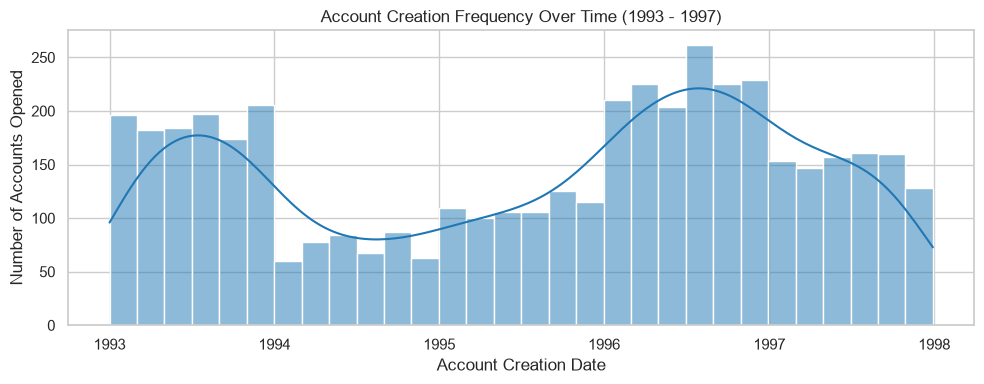

In [89]:
plt.figure(figsize=(10, 4))
sns.histplot(
    data=account, x="Account_date", bins=30, kde=True, color="#1f77b4"
)
plt.title("Account Creation Frequency Over Time (1993 - 1997)")
plt.xlabel("Account Creation Date")
plt.ylabel("Number of Accounts Opened")
plt.tight_layout()
plt.show()

C:\Users\saleh\AppData\Local\Temp\ipykernel_29928\2603240126.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


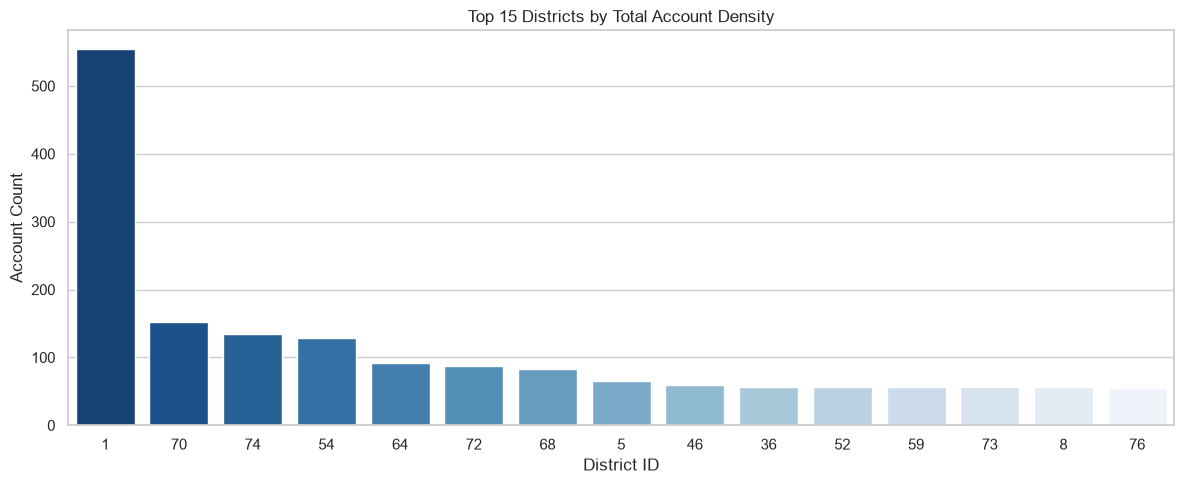

In [ ]:
plt.figure(figsize=(12, 5))
top_districts = account["district_id"].value_counts().head(15)
sns.barplot(
    x=top_districts.index,
    y=top_districts.values,
    palette="Blues_r",
    order=top_districts.index,
)
plt.title("Top 15 Districts by Total Account Density")
plt.xlabel("District ID")
plt.ylabel("Account Count")
plt.tight_layout()
plt.show()

In [ ]:
account["frequency"].value_counts()

frequency
monthly              4167
weekly                240
after_transaction      93
Name: count, dtype: int64